# Router Inference & Analysis (with W&B logging)

This notebook:
- Loads the trained multimodal router checkpoint
- Runs inference on the test router dataset
- Computes and plots multiple evaluation metrics (confusion matrix, per-task accuracy, per-model usage, ablations)
- Optionally logs all plots & metrics to Weights & Biases (W&B)
- Saves inference results and figures to disk so you can download them.

Set the paths and W&B settings in the `InferenceConfig` cell below, then run all cells.

In [1]:
import os
import io
import json
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Optional

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    CLIPImageProcessor,
    CLIPVisionModel,
)

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

try:
    import wandb
except ImportError:
    wandb = None
    print("wandb is not installed; W&B logging will be disabled.")

print("Imports done. Torch version:", torch.__version__)

/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Imports done. Torch version: 2.9.1+cu128


In [2]:
# ---- Config ----
@dataclass
class InferenceConfig:
    # Paths
    project_root: Path = Path.cwd().parent  # adjust if needed
    data_root: Path = Path.cwd().parent.parent.parent / "dataset" / "final_dataset"
    # router_subdir: str = "router_lexico"  # where train datasets were written
    router_subdir: str = "router_final"  # where train datasets were written
    test_file: str = "router_test_final.parquet"

    # Checkpoint path (update this to your actual checkpoint)
    checkpoint_path: Path = Path.cwd() / "saved_output" / "router_checkpoints_vision" / "best_model.pt"

    # Training history JSON path (saved by training notebook)
    training_history_path: Optional[Path] = Path.cwd() / "saved_output" / "router_checkpoints_vision" / "router_training_history.json"

    # Output dir for inference artifacts (plots, CSVs, etc.)
    output_dir: Path = Path.cwd() / "router_inference_outputs"

    # Model names (must match training)
    vision_encoder_name: str = "openai/clip-vit-base-patch32"
    text_encoder_name: str   = "distilbert-base-uncased"
    text_tokenizer_name: str = "distilbert-base-uncased"

    use_image: bool = True
    freeze_vision: bool = True
    freeze_text_encoder: bool = False

    max_text_length: int = 256
    eval_batch_size: int = 32
    num_workers: int = 4

    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42

    # Weights & Biases
    use_wandb: bool = False  # set to True to enable W&B logging
    wandb_project: str = "vlm-router"
    wandb_entity: Optional[str] = None  # your W&B username or team, or None
    wandb_run_name: str = "router_inference"


config = InferenceConfig()

def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.seed)

print(config)
print("Using device:", config.device)

# Ensure output directory exists
config.output_dir.mkdir(parents=True, exist_ok=True)
print("Output dir:", config.output_dir)

# ---- W&B init ----
run = None
if config.use_wandb:
    if wandb is None:
        raise ImportError("wandb is not installed but config.use_wandb is True.")
    wandb_kwargs = dict(
        project=config.wandb_project,
        name=config.wandb_run_name,
        config=asdict(config),
    )
    if config.wandb_entity is not None:
        wandb_kwargs["entity"] = config.wandb_entity
    run = wandb.init(**wandb_kwargs)
    print("Initialized W&B run:", run.name)
else:
    print("W&B logging disabled (config.use_wandb=False).")


def log_and_save_figure(fig, key: str):
    """Save matplotlib figure to disk and optionally log to W&B."""
    out_path = config.output_dir / f"{key}.png"
    fig.savefig(out_path, bbox_inches="tight")
    print(f"Saved figure to {out_path}")
    if config.use_wandb and wandb is not None:
        wandb.log({key: wandb.Image(fig)})


def finish_wandb():
    if config.use_wandb and wandb is not None and wandb.run is not None:
        wandb.finish()
        print("Finished W&B run.")

InferenceConfig(project_root=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm'), data_root=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset'), router_subdir='router_final', test_file='router_test_final.parquet', checkpoint_path=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/saved_output/router_checkpoints_vision/best_model.pt'), training_history_path=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/saved_output/router_checkpoints_vision/router_training_history.json'), output_dir=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_inference_outputs'), vision_encoder_name='openai/clip-vit-base-patch32', text_encoder_name='distilbert-base-uncased', text_tokenizer_name='distilbert-base-uncased', use_image=True, freeze_vision=True, freeze_text_encoder=False, max_text_length=256, eval_batch_size=32, num_workers=4

In [3]:
# ---- Load test parquet ----
router_dir = config.data_root / config.router_subdir
test_path = router_dir / config.test_file

print("Router data dir:", router_dir)
print("Test path:", test_path)

test_df = pd.read_parquet(test_path)

print("test_df shape:", test_df.shape)
print("Columns (first 40):")
print(test_df.columns[:40])

display(test_df.head())

# Utility metadata (for context)
if "utility_scheme" in test_df.columns:
    DATA_UTILITY_SCHEME = str(test_df["utility_scheme"].iloc[0])
else:
    DATA_UTILITY_SCHEME = "unknown"

HIER_W_SAMPLE = float(test_df.get("hier_w_sample", pd.Series([np.nan])).iloc[0])
HIER_W_TASK   = float(test_df.get("hier_w_task",   pd.Series([np.nan])).iloc[0])
HIER_W_GLOBAL = float(test_df.get("hier_w_global", pd.Series([np.nan])).iloc[0])

print("\nUtility metadata:")
print("  utility_scheme:", DATA_UTILITY_SCHEME)
print("  hier_w_sample :", HIER_W_SAMPLE)
print("  hier_w_task   :", HIER_W_TASK)
print("  hier_w_global :", HIER_W_GLOBAL)

Router data dir: /storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset/router_final
Test path: /storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset/router_final/router_test_final.parquet
test_df shape: (13707, 50)
Columns (first 40):
Index(['sample_id', 'image_path', 'image_bytes_hash', 'prompt_raw',
       'img_width', 'img_height', 'img_aspect_ratio',
       'txt_prompt_length_chars', 'txt_prompt_length_words', 'router_task',
       'source_dataset', 'source_config', 'txt_question_type',
       'txt_has_mc_options', 'ground_truth', 'ground_truth_type',
       'router_best_model_id', 'router_best_model_name', 'router_chosen_perf',
       'router_chosen_cost', 'router_soft_p_deepseek_ocr',
       'router_soft_p_qwen2_5_vl_3b', 'router_soft_p_qwen2_5_vl_7b',
       'router_soft_p_qwen3_vl_8b_thinking', 'router_soft_p_gemma_3_27b',
       'deepseek_ocr__sample_score', 'deepseek_ocr__cost',
       'deepseek_ocr__valid_mask', 'deepseek_ocr__is_correct',
   

,sample_id,image_path,image_bytes_hash,prompt_raw,img_width,img_height,img_aspect_ratio,txt_prompt_length_chars,txt_prompt_length_words,router_task,...,qwen3_vl_8b_thinking__sample_score,qwen3_vl_8b_thinking__cost,qwen3_vl_8b_thinking__valid_mask,qwen3_vl_8b_thinking__is_correct,qwen3_vl_8b_thinking__score_f1,gemma_3_27b__sample_score,gemma_3_27b__cost,gemma_3_27b__valid_mask,gemma_3_27b__is_correct,gemma_3_27b__score_f1
0,ai2d_00004_bf3d9c5fd30bf304,None,bf3d9c5fd30bf304,Question: If the Termites in the community bel...,1100.0,532.0,2.068,211.0,34.0,diagram_reasoning,...,0.850000,0.001191,True,True,0.000000,0.853030,0.000060,True,True,0.030303
1,ai2d_00007_e6f58451a22503d1,None,e6f58451a22503d1,Question: what does the 2nd picture show?\nCho...,1500.0,1344.0,1.116,162.0,27.0,diagram_reasoning,...,0.853226,0.000758,True,True,0.032258,0.154651,0.000042,True,False,0.046512
2,ai2d_00019_e5f934cfc0951972,None,e5f934cfc0951972,Question: A food web for a ecosystem is shown ...,305.0,297.0,1.027,223.0,40.0,diagram_reasoning,...,-0.050000,0.001104,True,False,0.000000,0.157273,0.000059,True,False,0.072727
3,ai2d_00021_59cfa73bc8485386,None,59cfa73bc8485386,Question: What is the lowermost section of a v...,1402.0,891.0,1.574,166.0,27.0,diagram_reasoning,...,0.155479,0.000672,True,False,0.054795,0.853846,0.000050,True,True,0.038462
4,ai2d_00023_bd686a44c25987c8,None,bd686a44c25987c8,Question: What is the insulating envelope of m...,549.0,284.0,1.933,229.0,39.0,diagram_reasoning,...,0.156154,0.000414,True,False,0.061538,0.940000,0.000030,True,True,0.400000



Utility metadata:
  utility_scheme: unknown
  hier_w_sample : nan
  hier_w_task   : nan
  hier_w_global : nan


In [4]:
# ---- Visual sanity check: show one random test sample ----
import random

rand_idx = random.randint(0, len(test_df) - 1)
row = test_df.iloc[rand_idx]

print("Random sample index:", rand_idx)
print("sample_id:", row.get("sample_id"))
print("router_task:", row.get("router_task"))
print("router_best_model_id:", row.get("router_best_model_id"))
print("router_best_model_name:", row.get("router_best_model_name"))
print("\nPrompt:")
print(row.get("prompt_raw"))

if "image_png" in row and isinstance(row["image_png"], (bytes, bytearray, memoryview)):
    img = Image.open(io.BytesIO(row["image_png"])).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Random test image")
    plt.show()
else:
    print("No image_png bytes found for this sample.")

Random sample index: 10476
sample_id: tabmwp_01794_931a767278fd6040
router_task: table_math
router_best_model_id: 1
router_best_model_name: qwen2_5_vl_3b

Prompt:
Look at the following schedule. When does the track meet end?
No image_png bytes found for this sample.


In [5]:
# ---- RouterDataset (inference) ----
class RouterDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        image_processor: CLIPImageProcessor,
        tokenizer,
        config: InferenceConfig,
        model_names: List[str],
    ):
        self.df = df.reset_index(drop=True)
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.config = config
        self.model_names = model_names

    def __len__(self):
        return len(self.df)

    def _load_image(self, row) -> torch.Tensor:
        # Prefer image_png bytes
        if "image_png" in row.index:
            img_bytes = row["image_png"]
            if isinstance(img_bytes, (bytes, bytearray, memoryview)):
                try:
                    pil_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                    inputs = self.image_processor(images=pil_img, return_tensors="pt")
                    pixel_values = inputs["pixel_values"].squeeze(0)
                    return pixel_values
                except Exception as e:
                    print(f"[WARN] Failed to decode image_png for sample_id={row.get('sample_id', 'NA')}: {e}")

        # Fallback: black image
        return torch.zeros(3, 224, 224)

    def _build_router_text(self, row) -> str:
        prompt = row.get("prompt_raw", "")

        w = row.get("img_width", None)
        h = row.get("img_height", None)
        ar = row.get("img_aspect_ratio", None)
        len_chars = row.get("txt_prompt_length_chars", None)
        len_words = row.get("txt_prompt_length_words", None)

        meta_parts = []
        if len_words is not None and not np.isnan(len_words):
            meta_parts.append(f"PromptLenWords: {int(len_words)}.")
        if len_chars is not None and not np.isnan(len_chars):
            meta_parts.append(f"PromptLenChars: {int(len_chars)}.")
        if w is not None and h is not None and not np.isnan(w) and not np.isnan(h):
            meta_parts.append(f"ImageWidth: {int(w)}. ImageHeight: {int(h)}.")
        if ar is not None and not np.isnan(ar):
            meta_parts.append(f"ImageAR: {float(ar):.2f}.")

        meta_str = " ".join(meta_parts)
        router_text = f"{meta_str} Question: {prompt}"
        return router_text

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        if self.config.use_image:
            pixel_values = self._load_image(row)
        else:
            pixel_values = torch.zeros(3, 224, 224)
        pixel_values = pixel_values.float()

        # Text
        router_text = self._build_router_text(row)
        encoding = self.tokenizer(
            router_text,
            padding="max_length",
            truncation=True,
            max_length=self.config.max_text_length,
            return_tensors="pt",
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        label = int(row["router_best_model_id"])  # ground-truth best model

        return {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": label,
            "sample_id": row.get("sample_id"),
            "router_task": row.get("router_task"),
        }

In [6]:
# ---- Tokenizer, processor, dataset, dataloader ----
# Infer model_names from router_best_model_name mapping
if "router_best_model_id" in test_df.columns and "router_best_model_name" in test_df.columns:
    uniq = (
        test_df[["router_best_model_id", "router_best_model_name"]]
        .drop_duplicates()
        .sort_values("router_best_model_id")
    )
    model_names = uniq["router_best_model_name"].tolist()
else:
    raise ValueError("router_best_model_id / router_best_model_name not found in test_df.")

num_models = len(model_names)
print("Model names:", model_names)
print("Number of models:", num_models)

image_processor = CLIPImageProcessor.from_pretrained(config.vision_encoder_name)
tokenizer = AutoTokenizer.from_pretrained(config.text_tokenizer_name)

test_dataset = RouterDataset(test_df, image_processor, tokenizer, config, model_names)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.eval_batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=True,
)

print("Test DataLoader ready.")

Model names: ['deepseek_ocr', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking', 'gemma_3_27b']
Number of models: 5
Test DataLoader ready.


In [7]:
# ---- Multimodal Router Model (must match training) ----
class MultimodalRouterModel(nn.Module):
    def __init__(
        self,
        config: InferenceConfig,
        num_models: int,
        model_names: List[str],
    ):
        super().__init__()
        self.config = config
        self.num_models = num_models
        self.model_names = model_names

        # Vision encoder (CLIP)
        self.vision = CLIPVisionModel.from_pretrained(config.vision_encoder_name)
        vision_hidden_size = self.vision.config.hidden_size

        # Text encoder
        self.text_encoder = AutoModel.from_pretrained(config.text_encoder_name)
        text_hidden_size = self.text_encoder.config.hidden_size

        hidden_dim = max(vision_hidden_size, text_hidden_size)
        self.vision_proj = nn.Linear(vision_hidden_size, hidden_dim)
        self.text_proj   = nn.Linear(text_hidden_size, hidden_dim)

        fused_dim = hidden_dim * 2
        self.fusion_mlp = nn.Sequential(
            nn.Linear(fused_dim, fused_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(fused_dim, hidden_dim),
            nn.ReLU(),
        )

        self.classifier = nn.Linear(hidden_dim, num_models)

        if config.freeze_vision:
            for p in self.vision.parameters():
                p.requires_grad = False

        if config.freeze_text_encoder:
            for p in self.text_encoder.parameters():
                p.requires_grad = False

    def forward(self, pixel_values, input_ids, attention_mask):
        vision_outputs = self.vision(pixel_values=pixel_values)
        vision_emb = vision_outputs.pooler_output
        vision_emb = self.vision_proj(vision_emb)

        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        if hasattr(text_outputs, "pooler_output") and text_outputs.pooler_output is not None:
            text_emb = text_outputs.pooler_output
        else:
            last_hidden = text_outputs.last_hidden_state
            mask = attention_mask.unsqueeze(-1).float()
            text_emb = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        text_emb = self.text_proj(text_emb)

        fused = torch.cat([vision_emb, text_emb], dim=-1)
        fused = self.fusion_mlp(fused)

        logits = self.classifier(fused)
        return logits

In [8]:
# ---- Instantiate model & load checkpoint ----
model = MultimodalRouterModel(config, num_models=num_models, model_names=model_names)
model = model.to(config.device)

if config.checkpoint_path.exists():
    print("Loading checkpoint from:", config.checkpoint_path)
    state = torch.load(config.checkpoint_path, map_location=config.device, weights_only=False)
    # state can be either full state dict or {"model_state_dict": ...}
    if isinstance(state, dict) and "state_dict" in state:
        model.load_state_dict(state["state_dict"])
    elif isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
    else:
        model.load_state_dict(state)
    print("Checkpoint loaded.")
else:
    print("WARNING: checkpoint not found at", config.checkpoint_path)
    print("Using randomly initialized weights (for debugging only).")

Using randomly initialized weights (for debugging only).


In [9]:
# ---- Optional: load & plot training history ----
history = None
if config.training_history_path is not None and config.training_history_path.exists():
    with open(config.training_history_path, "r") as f:
        history = json.load(f)
    print("Loaded training history from", config.training_history_path)

    epochs = range(1, len(history.get("train_loss", [])) + 1)
    if len(list(epochs)) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Loss
        axes[0].plot(epochs, history.get("train_loss", []), label="Train")
        axes[0].plot(epochs, history.get("val_loss", []), label="Val")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].set_title("Loss vs Epoch")
        axes[0].legend()

        # Accuracy
        axes[1].plot(epochs, history.get("train_acc", []), label="Train")
        axes[1].plot(epochs, history.get("val_acc", []), label="Val")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].set_title("Accuracy vs Epoch")
        axes[1].legend()

        plt.tight_layout()
        log_and_save_figure(fig, "training_curves")
        plt.show()
    else:
        print("Training history JSON is present but appears empty.")
else:
    print("No training_history_path found at", config.training_history_path)

No training_history_path found at /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/saved_output/router_checkpoints_vision/router_training_history.json


In [14]:
import time
import torch
import psutil
import numpy as np

class RouterProfiler:
    def __init__(self, use_cuda=True):
        self.use_cuda = use_cuda and torch.cuda.is_available()
        self.latencies = []
        self.cpu_mem = []
        self.gpu_mem = []

    def start(self):
        self.cpu_mem_before = psutil.Process().memory_info().rss

        if self.use_cuda:
            torch.cuda.reset_peak_memory_stats()
            self.gpu_mem_before = torch.cuda.memory_allocated()

        if self.use_cuda:
            torch.cuda.synchronize()
        self.t0 = time.time()

    def stop(self):
        if self.use_cuda:
            torch.cuda.synchronize()
        t1 = time.time()

        self.latencies.append(t1 - self.t0)

        mem_after = psutil.Process().memory_info().rss
        self.cpu_mem.append(mem_after - self.cpu_mem_before)

        if self.use_cuda:
            peak = torch.cuda.max_memory_allocated()
            self.gpu_mem.append(peak - self.gpu_mem_before)

    def summary(self):
        return {
            "latency_ms_mean": np.mean(self.latencies) * 1000,
            "latency_ms_std": np.std(self.latencies) * 1000,
            "cpu_mem_mb_mean": np.mean(self.cpu_mem) / (1024 ** 2),
            "gpu_mem_mb_mean": np.mean(self.gpu_mem) / (1024 ** 2) if self.use_cuda and self.gpu_mem else None,
            "gpu_mem_mb_peak": max(self.gpu_mem) / (1024 ** 2) if self.use_cuda and self.gpu_mem else None,
        }


In [30]:
# ---- Inference helpers ----
@torch.no_grad()
def run_inference(
    model,
    loader,
    config: InferenceConfig,
    mode: str = "full",  # "full", "text_only", "image_only"
):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    all_sample_ids = []
    all_tasks = []

    for batch in loader:
        pixel_values = batch["pixel_values"].to(config.device)
        input_ids = batch["input_ids"].to(config.device)
        attention_mask = batch["attention_mask"].to(config.device)
        labels = batch["label"].to(config.device)

        # Ablations
        if mode == "text_only":
            pixel_values = torch.zeros_like(pixel_values)
        elif mode == "image_only":
            pad_id = tokenizer.pad_token_id or 0
            input_ids = torch.full_like(input_ids, pad_id)
            attention_mask = torch.zeros_like(attention_mask)

        logits = model(pixel_values, input_ids, attention_mask)
        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_sample_ids.extend(batch["sample_id"])
        all_tasks.extend(batch["router_task"])

    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    acc = (all_labels == all_preds).mean()

    results = pd.DataFrame({
        "sample_id": all_sample_ids,
        "router_task": all_tasks,
        "label_id": all_labels,
        "pred_id": all_preds,
        "mode": mode,
    })

    return acc, results, all_probs

In [ ]:
# import torch
# import numpy as np
# import pandas as pd

# def run_inference(model, dataloader, config, mode="full"):
#     """
#     Run router inference with optional text-only / image-only modes,
#     profile latency + memory, and log stats to W&B.

#     Returns:
#         acc: float
#         results_df: pd.DataFrame
#         all_probs: np.ndarray (N, num_classes)
#     """
#     model.eval()

#     # Infer device
#     device = getattr(config, "device", None)
#     if device is None:
#         device = next(model.parameters()).device

#     use_cuda = (hasattr(device, "type") and device.type == "cuda")
#     profiler = RouterProfiler(use_cuda=use_cuda)

#     all_preds = []
#     all_labels = []
#     all_probs = []
#     result_rows = []

#     label_key = None  # auto-detect on first batch

#     print(f"Running inference in mode='{mode}' on {len(dataloader)} batches...")

#     with torch.no_grad():
#         for step, batch in enumerate(dataloader, start=1):
#             # -------------------------
#             # Auto-detect label key once
#             # -------------------------
#             if label_key is None:
#                 candidate_keys = [
#                     "labels",
#                     "label",
#                     "router_best_model_id",
#                     "router_best_model_idx",
#                     "target",
#                     "targets",
#                     "y",
#                 ]
#                 available = list(batch.keys())
#                 for k in candidate_keys:
#                     if k in batch:
#                         label_key = k
#                         break
#                 if label_key is None:
#                     raise KeyError(
#                         f"No label key found in batch. "
#                         f"Tried {candidate_keys}, batch has keys: {available}"
#                     )
#                 print(f"[run_inference] Using label key: '{label_key}'")

#             # -------------------------
#             # Build model_inputs dict
#             #   - move tensors to device
#             #   - drop labels / metadata
#             # -------------------------
#             model_inputs = {}
#             for k, v in batch.items():
#                 if k in {label_key, "sample_id", "router_task", "source_dataset"}:
#                     continue  # not passed into model

#                 if torch.is_tensor(v):
#                     model_inputs[k] = v.to(device)
#                 else:
#                     model_inputs[k] = v  # non-tensor metadata if any

#             # Apply mode masking if fields exist
#             if mode == "text_only" and "pixel_values" in model_inputs:
#                 model_inputs["pixel_values"] = torch.zeros_like(model_inputs["pixel_values"])
#             elif mode == "image_only" and "input_ids" in model_inputs:
#                 model_inputs["input_ids"] = torch.zeros_like(model_inputs["input_ids"])

#             # -------------------------
#             # Labels (stay on CPU for metrics)
#             # -------------------------
#             labels_raw = batch[label_key]
#             if torch.is_tensor(labels_raw):
#                 labels_cpu = labels_raw.cpu()
#             else:
#                 labels_cpu = torch.as_tensor(labels_raw)

#             # -------------------------
#             # Profiled forward pass
#             # -------------------------
#             profiler.start()
#             outputs = model(**model_inputs)
#             profiler.stop()

#             # -------------------------
#             # Robustly extract logits
#             # -------------------------
#             if isinstance(outputs, torch.Tensor):
#                 logits = outputs
#             elif hasattr(outputs, "logits"):
#                 logits = outputs.logits
#             elif isinstance(outputs, (tuple, list)) and len(outputs) > 0:
#                 logits = outputs[0]
#             elif isinstance(outputs, dict) and "logits" in outputs:
#                 logits = outputs["logits"]
#             else:
#                 raise TypeError(
#                     f"Unsupported model output type: {type(outputs)}. "
#                     f"Expected Tensor, object with .logits, tuple/list, or dict with 'logits'."
#                 )

#             probs = torch.softmax(logits, dim=-1)
#             preds = torch.argmax(probs, dim=-1)

#             preds_cpu  = preds.cpu()
#             probs_cpu  = probs.cpu()

#             all_preds.append(preds_cpu)
#             all_labels.append(labels_cpu)
#             all_probs.append(probs_cpu)

#             # Sample IDs if present
#             sample_ids = batch.get("sample_id", None)
#             if sample_ids is not None:
#                 if torch.is_tensor(sample_ids):
#                     sample_ids = sample_ids.cpu().numpy().tolist()
#                 else:
#                     sample_ids = list(sample_ids)
#             else:
#                 sample_ids = [None] * preds_cpu.shape[0]

#             # Build per-sample rows
#             for sid, y_true, y_pred in zip(
#                 sample_ids,
#                 labels_cpu.numpy().tolist(),
#                 preds_cpu.numpy().tolist(),
#             ):
#                 result_rows.append({
#                     "mode": mode,
#                     "sample_id": sid,
#                     "label": y_true,
#                     "pred": y_pred,
#                 })

#             if step % 50 == 0 or step == len(dataloader):
#                 print(f"[{step}/{len(dataloader)}] processed")

#     # -------------------------
#     # Aggregate metrics
#     # -------------------------
#     all_preds_arr  = torch.cat(all_preds).numpy()
#     all_labels_arr = torch.cat(all_labels).numpy()
#     all_probs_arr  = torch.cat(all_probs).numpy()

#     acc = float((all_preds_arr == all_labels_arr).mean())
#     results_df = pd.DataFrame(result_rows)

#     prof_stats = profiler.summary()

#     print(f"\n[{mode}] accuracy: {acc:.4f}")
#     print("=== PROFILING SUMMARY ===")
#     for k, v in prof_stats.items():
#         print(f"{k}: {v:.4f}" if v is not None else f"{k}: {v}")

#     # -------------------------
#     # Log to W&B (if enabled)
#     # -------------------------
#     use_wandb = getattr(config, "use_wandb", False)
#     if use_wandb and "wandb" in globals() and wandb is not None:
#         log_dict = {
#             f"accuracy/{mode}": acc,
#             f"profile/{mode}_latency_ms_mean": float(prof_stats["latency_ms_mean"]),
#             f"profile/{mode}_latency_ms_std": float(prof_stats["latency_ms_std"]),
#             f"profile/{mode}_cpu_mem_mb_mean": float(prof_stats["cpu_mem_mb_mean"]),
#         }
#         if prof_stats.get("gpu_mem_mb_mean") is not None:
#             log_dict[f"profile/{mode}_gpu_mem_mb_mean"] = float(prof_stats["gpu_mem_mb_mean"])
#         if prof_stats.get("gpu_mem_mb_peak") is not None:
#             log_dict[f"profile/{mode}_gpu_mem_mb_peak"] = float(prof_stats["gpu_mem_mb_peak"])

#         wandb.log(log_dict)

#     return acc, results_df, all_probs_arr


In [31]:
# ---- Run inference for full, text-only, image-only ----
full_acc, full_results, full_probs = run_inference(model, test_loader, config, mode="full")
text_acc, text_results, text_probs = run_inference(model, test_loader, config, mode="text_only")
img_acc, img_results, img_probs   = run_inference(model, test_loader, config, mode="image_only")

print(f"Full (image+text) accuracy : {full_acc:.4f}")
print(f"Text-only accuracy        : {text_acc:.4f}")
print(f"Image-only accuracy       : {img_acc:.4f}")

if config.use_wandb and wandb is not None:
    wandb.log({
        "accuracy/full": float(full_acc),
        "accuracy/text_only": float(text_acc),
        "accuracy/image_only": float(img_acc),
    })

all_results = pd.concat([full_results, text_results, img_results], ignore_index=True)
display(all_results.head())

# Save results to disk for download
# results_parquet = config.output_dir / "router_inference_results.parquet"
# results_csv = config.output_dir / "router_inference_results.csv"
# all_results.to_parquet(results_parquet, index=False)
# all_results.to_csv(results_csv, index=False)
# print("Saved inference results to:")
# print("  ", results_parquet)
# print("  ", results_csv)

Full (image+text) accuracy : 0.2766
Text-only accuracy        : 0.2766
Image-only accuracy       : 0.2806


,sample_id,router_task,label_id,pred_id,mode
0,ai2d_00004_bf3d9c5fd30bf304,diagram_reasoning,1,2,full
1,ai2d_00007_e6f58451a22503d1,diagram_reasoning,1,2,full
2,ai2d_00019_e5f934cfc0951972,diagram_reasoning,4,2,full
3,ai2d_00021_59cfa73bc8485386,diagram_reasoning,1,2,full
4,ai2d_00023_bd686a44c25987c8,diagram_reasoning,1,2,full


Saved figure to /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_inference_outputs/confusion_matrix_full.png


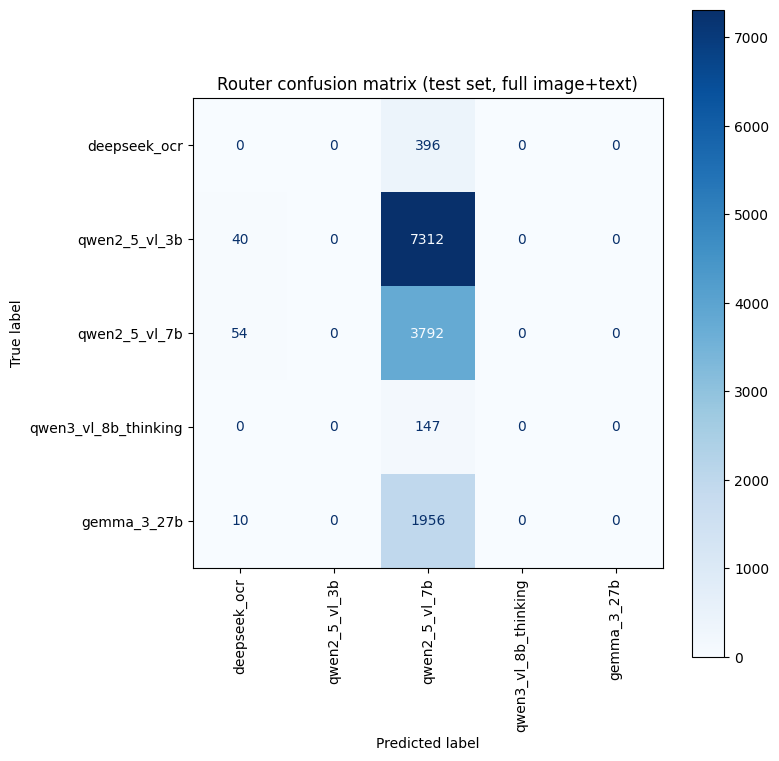

In [32]:
# ---- Confusion matrix (full model) ----
labels = list(range(num_models))
cm = confusion_matrix(full_results["label_id"], full_results["pred_id"], labels=labels)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_names)
disp.plot(include_values=True, xticks_rotation="vertical", cmap="Blues", ax=ax)
plt.title("Router confusion matrix (test set, full image+text)")
plt.tight_layout()
log_and_save_figure(fig, "confusion_matrix_full")
plt.show()

Per-task accuracy:


/home/hice1/vchopra37/scratch/models/tmp/ipykernel_160200/2971050302.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  task_acc = task_group.apply(lambda g: (g["label_id"] == g["pred_id"]).mean()).sort_values(ascending=False)


,router_task,accuracy,count
0,map_reasoning,0.870629,284
1,icon_reasoning,0.863787,602
2,counting,0.851590,1277
3,science_reasoning,0.752577,317
4,table_reasoning,0.570801,283
5,meme_classification,0.426966,285
6,scene_text_ocr,0.410345,45
7,general_vqa,0.403279,282
8,document_ocr,0.383333,313
9,difference_detection,0.341853,960


Saved figure to /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_inference_outputs/per_task_accuracy.png


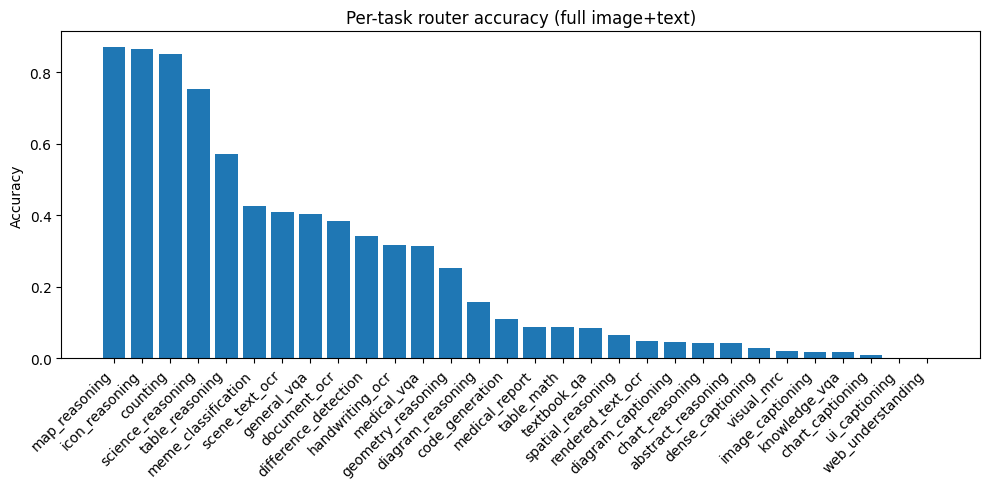

In [33]:
# ---- Per-task accuracy ----
task_group = full_results.groupby("router_task")
task_acc = task_group.apply(lambda g: (g["label_id"] == g["pred_id"]).mean()).sort_values(ascending=False)
task_counts = task_group.size()

task_acc_df = pd.DataFrame({
    "router_task": task_acc.index,
    "accuracy": task_acc.values,
    "count": task_counts.values,
})

print("Per-task accuracy:")
display(task_acc_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(task_acc_df["router_task"], task_acc_df["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Per-task router accuracy (full image+text)")
plt.tight_layout()
log_and_save_figure(fig, "per_task_accuracy")
plt.show()

if config.use_wandb and wandb is not None:
    # Log as a table as well
    wandb.log({"per_task_accuracy_table": wandb.Table(dataframe=task_acc_df)})

Per-model usage & accuracy:


,model_id,model_name,pred_count,label_count,accuracy_when_best
0,0,deepseek_ocr,104,396,0.000000
1,1,qwen2_5_vl_3b,0,7352,0.000000
2,2,qwen2_5_vl_7b,13603,3846,0.985959
3,3,qwen3_vl_8b_thinking,0,147,0.000000
4,4,gemma_3_27b,0,1966,0.000000


Saved figure to /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_inference_outputs/per_model_usage.png


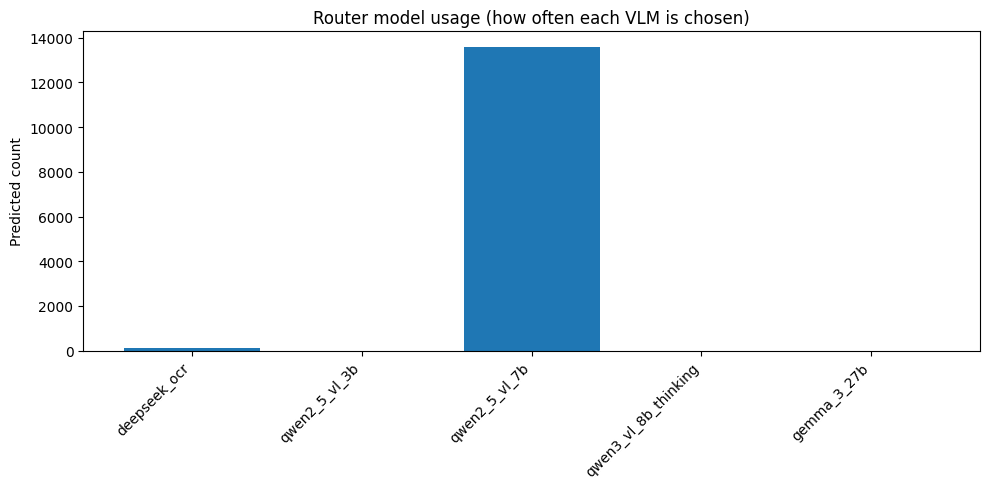

Saved figure to /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_inference_outputs/per_model_accuracy_when_best.png


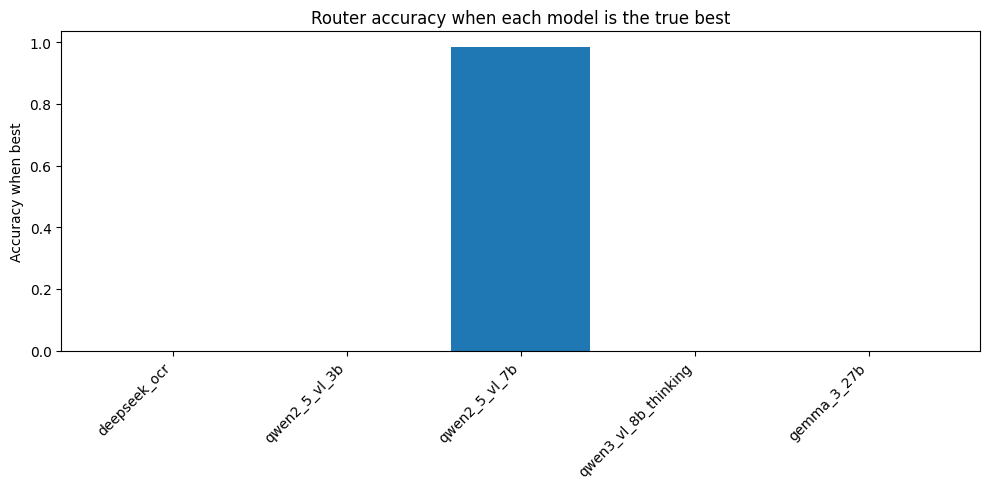

In [34]:
# ---- Per-model usage & accuracy ----
pred_counts = full_results["pred_id"].value_counts().sort_index()
true_counts = full_results["label_id"].value_counts().sort_index()

model_usage_df = pd.DataFrame({
    "model_id": range(num_models),
    "model_name": model_names,
    "pred_count": [pred_counts.get(i, 0) for i in range(num_models)],
    "label_count": [true_counts.get(i, 0) for i in range(num_models)],
})

model_acc = []
for i in range(num_models):
    mask = full_results["label_id"] == i
    if mask.sum() == 0:
        model_acc.append(np.nan)
    else:
        model_acc.append((full_results.loc[mask, "pred_id"] == i).mean())

model_usage_df["accuracy_when_best"] = model_acc

print("Per-model usage & accuracy:")
display(model_usage_df)

fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(model_usage_df["model_name"], model_usage_df["pred_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Predicted count")
plt.title("Router model usage (how often each VLM is chosen)")
plt.tight_layout()
log_and_save_figure(fig1, "per_model_usage")
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.bar(model_usage_df["model_name"], model_usage_df["accuracy_when_best"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy when best")
plt.title("Router accuracy when each model is the true best")
plt.tight_layout()
log_and_save_figure(fig2, "per_model_accuracy_when_best")
plt.show()

if config.use_wandb and wandb is not None:
    wandb.log({"per_model_usage_table": wandb.Table(dataframe=model_usage_df)})

Ablation summary:


,mode,accuracy
0,full (img+text),0.276647
1,text-only,0.276647
2,image-only,0.280587


Saved figure to /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_inference_outputs/ablation_full_text_image.png


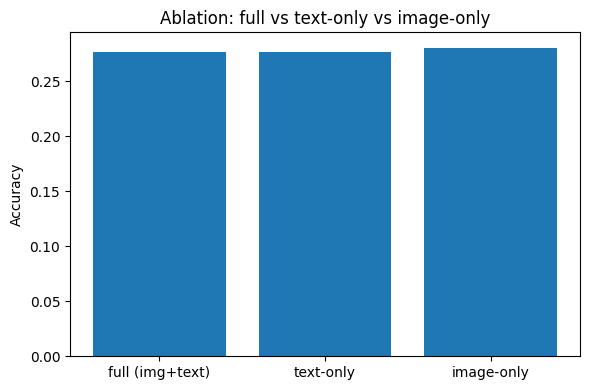

In [35]:
# ---- Ablation summary plot ----
modes = ["full (img+text)", "text-only", "image-only"]
accs = [full_acc, text_acc, img_acc]

ablation_df = pd.DataFrame({
    "mode": modes,
    "accuracy": accs,
})
print("Ablation summary:")
display(ablation_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ablation_df["mode"], ablation_df["accuracy"])
plt.ylabel("Accuracy")
plt.title("Ablation: full vs text-only vs image-only")
plt.tight_layout()
log_and_save_figure(fig, "ablation_full_text_image")
plt.show()

if config.use_wandb and wandb is not None:
    wandb.log({"ablation_table": wandb.Table(dataframe=ablation_df)})

In [36]:
# ---- Qualitative examples ----
def show_example(row_idx: int, df: pd.DataFrame, base_df: pd.DataFrame):
    row = df.iloc[row_idx]
    sid = row["sample_id"]
    label_id = row["label_id"]
    pred_id = row["pred_id"]

    base_row = base_df[base_df["sample_id"] == sid].iloc[0]

    print(f"Index: {row_idx}")
    print(f"sample_id      : {sid}")
    print(f"router_task    : {row['router_task']}")
    print(f"GT best model  : {model_names[label_id]} (id={label_id})")
    print(f"Predicted model: {model_names[pred_id]} (id={pred_id})")
    print("\nPrompt:")
    print(base_row.get("prompt_raw", ""))

    if "image_png" in base_row and isinstance(base_row["image_png"], (bytes, bytearray, memoryview)):
        img = Image.open(io.BytesIO(base_row["image_png"])).convert("RGB")
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title("Image")
        plt.show()
    else:
        print("No image available.")

correct_mask = full_results["label_id"] == full_results["pred_id"]
incorrect_mask = ~correct_mask

print("Correct examples (first 3):")
for idx in full_results[correct_mask].index[:3]:
    show_example(idx, full_results, test_df)
    print("=" * 80)

print("Incorrect examples (first 3):")
for idx in full_results[incorrect_mask].index[:3]:
    show_example(idx, full_results, test_df)
    print("=" * 80)

Correct examples (first 3):
Index: 20
sample_id      : ai2d_00161_3d6a73d15b035832
router_task    : diagram_reasoning
GT best model  : qwen2_5_vl_7b (id=2)
Predicted model: qwen2_5_vl_7b (id=2)

Prompt:
Question: What is stage D?
Choices:
A. Gross
B. Adult Frog
C. Egg
D. Late Tadpole
Answer with the letter.
No image available.
Index: 35
sample_id      : ai2d_00303_1edc70add56c6c0e
router_task    : diagram_reasoning
GT best model  : qwen2_5_vl_7b (id=2)
Predicted model: qwen2_5_vl_7b (id=2)

Prompt:
Question: In the life cycle of mosquito, what stage occurs after pupa?
Choices:
A. eggs
B. larva
C. adult emerging
D. blood feeding female
Answer with the letter.
No image available.
Index: 38
sample_id      : ai2d_00307_e01e92551c83fb67
router_task    : diagram_reasoning
GT best model  : qwen2_5_vl_7b (id=2)
Predicted model: qwen2_5_vl_7b (id=2)

Prompt:
Question: Which has the smoothest edges?
Choices:
A. lacerate
B. serrate
C. entire
D. crenate
Answer with the letter.
No image available.


In [37]:
# ---- Collect router predictions on test set (sample-level) ----
@torch.no_grad()
def collect_test_predictions(model, loader, df_test, config):
    model.eval()
    all_preds = []
    all_labels = []
    all_sample_ids = []

    # Assumes DataLoader uses default SequentialSampler (shuffle=False)
    for batch_idx, batch in enumerate(loader):
        pixel_values = batch["pixel_values"].to(config.device)
        input_ids = batch["input_ids"].to(config.device)
        attention_mask = batch["attention_mask"].to(config.device)
        labels = batch["label"].to(config.device)

        logits = model(pixel_values, input_ids, attention_mask)
        preds = logits.argmax(dim=-1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        # Map batch indices back to df_test rows
        start_idx = batch_idx * config.eval_batch_size
        end_idx = start_idx + preds.size(0)
        batch_indices = list(range(start_idx, end_idx))
        sample_ids = df_test.iloc[batch_indices]["sample_id"].tolist()
        all_sample_ids.extend(sample_ids)

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    results = pd.DataFrame({
        "sample_id": all_sample_ids,
        "router_pred_model_id": all_preds,
        "router_label_id": all_labels,
    })

    # Attach nice model names if available
    if "router_best_model_name" in df_test.columns and "router_best_model_id" in df_test.columns:
        id_to_name = (
            df_test[["router_best_model_id", "router_best_model_name"]]
            .drop_duplicates()
            .set_index("router_best_model_id")["router_best_model_name"]
            .to_dict()
        )
        results["router_pred_model_name"] = results["router_pred_model_id"].map(id_to_name)

    return results


# Run collection
router_test_results = collect_test_predictions(model, test_loader, test_df, config)
print("Router test predictions preview:")
display(router_test_results.head())

# (Optional) save to disk
router_test_results_path = config.output_dir / "router_test_predictions.parquet"
router_test_results.to_parquet(router_test_results_path, index=False)
print("Saved router_test_results to:", router_test_results_path)


Router test predictions preview:


,sample_id,router_pred_model_id,router_label_id,router_pred_model_name
0,ai2d_00004_bf3d9c5fd30bf304,2,1,qwen2_5_vl_7b
1,ai2d_00007_e6f58451a22503d1,2,1,qwen2_5_vl_7b
2,ai2d_00019_e5f934cfc0951972,2,4,qwen2_5_vl_7b
3,ai2d_00021_59cfa73bc8485386,2,1,qwen2_5_vl_7b
4,ai2d_00023_bd686a44c25987c8,2,1,qwen2_5_vl_7b


Saved router_test_results to: /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_inference_outputs/router_test_predictions.parquet


Overall acc   : 0.2766
Balanced acc  : 0.1972

Per-class accuracy (when that model is the true best):
  deepseek_ocr                   acc_when_best = 0.000
  qwen2_5_vl_3b                  acc_when_best = 0.000
  qwen2_5_vl_7b                  acc_when_best = 0.986
  qwen3_vl_8b_thinking           acc_when_best = 0.000
  gemma_3_27b                    acc_when_best = 0.000
Saved figure to /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_inference_outputs/per_class_accuracy.png


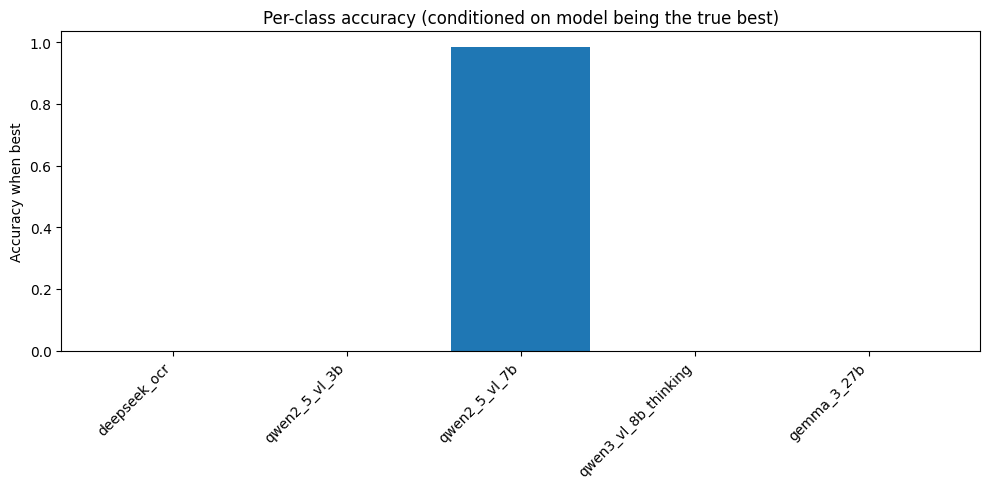

In [38]:
# ---- Per-class accuracy diagnostics ----
# Build label / prediction arrays from router_test_results
all_labels = router_test_results["router_label_id"].to_numpy()
all_preds  = router_test_results["router_pred_model_id"].to_numpy()

per_class_acc = []
for cid in range(num_models):
    mask = (all_labels == cid)
    if mask.sum() == 0:
        per_class_acc.append(np.nan)
    else:
        per_class_acc.append((all_preds[mask] == all_labels[mask]).mean())

overall_acc = (all_labels == all_preds).mean()
balanced_acc = np.nanmean(per_class_acc)

print(f"Overall acc   : {overall_acc:.4f}")
print(f"Balanced acc  : {balanced_acc:.4f}")
print("\nPer-class accuracy (when that model is the true best):")
for cid, acc in enumerate(per_class_acc):
    print(f"  {model_names[cid]:<30} acc_when_best = {acc:.3f}")

# ---- Per-class accuracy bar plot ----
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(num_models)

ax.bar(x, per_class_acc)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha="right")
ax.set_ylabel("Accuracy when best")
ax.set_title("Per-class accuracy (conditioned on model being the true best)")
plt.tight_layout()

# Save + (optionally) log to W&B
log_and_save_figure(fig, "per_class_accuracy")

if config.use_wandb and wandb is not None:
    wandb.log({
        "test/overall_acc": float(overall_acc),
        "test/balanced_acc": float(balanced_acc),
        **{f"test/class_acc/{model_names[i]}": float(per_class_acc[i])
           for i in range(num_models)}
    })


Saved figure to /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_inference_outputs/task_model_distribution.png


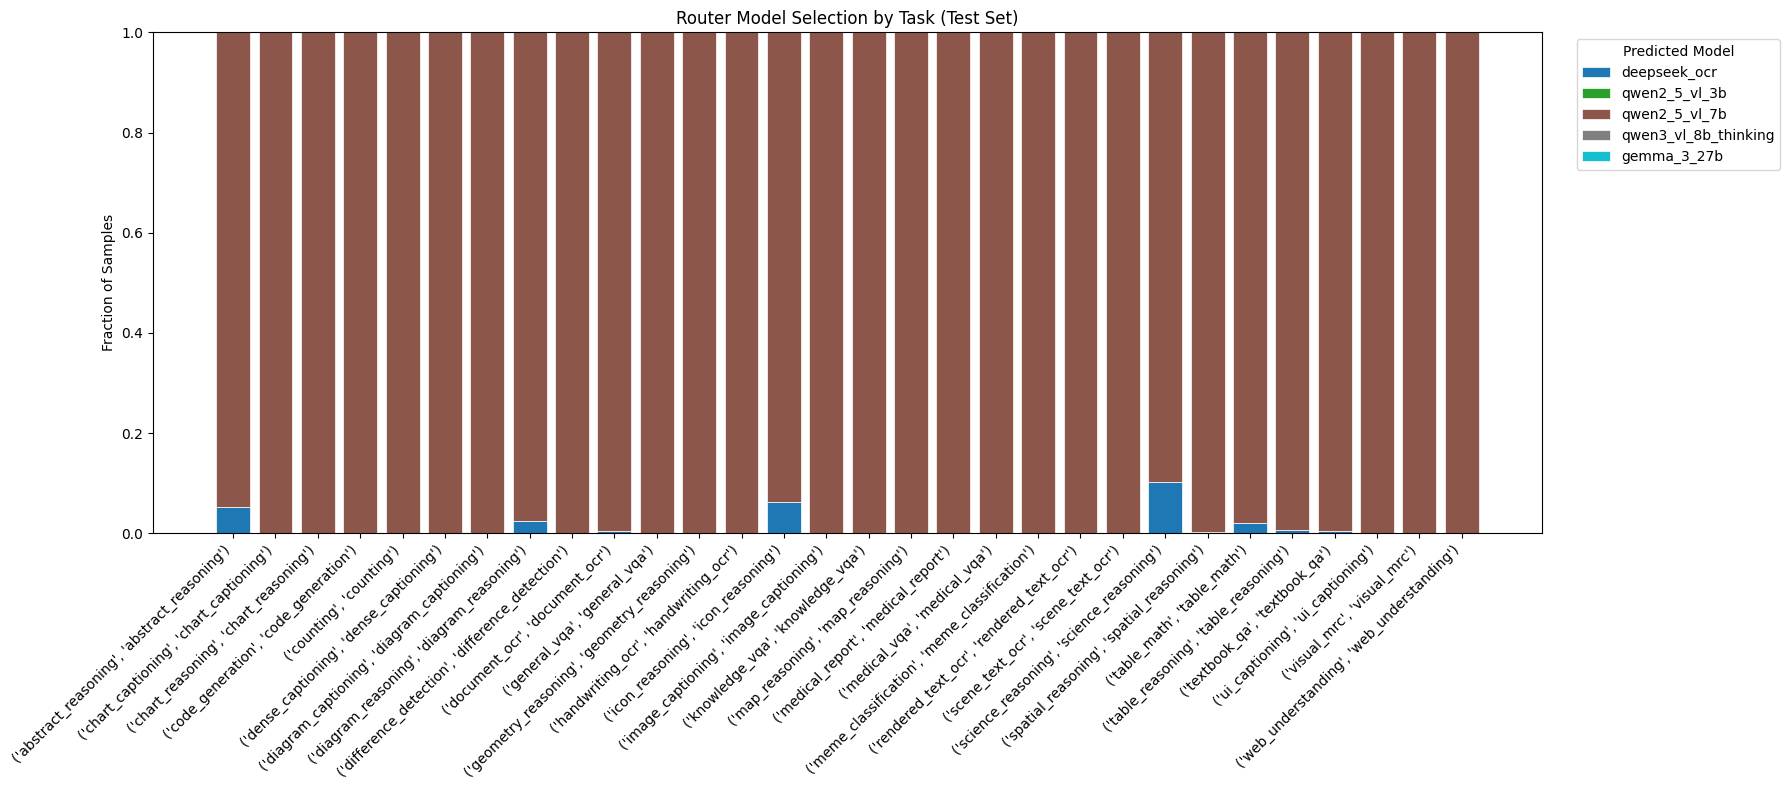

In [39]:
# ---- Router model selection by task (stacked bar) ----

# 1. Build full_results from router_test_results and attach router_task
#    (router_task lives in test_df, so we merge on sample_id)
full_results = router_test_results.copy()

# Attach router_task from test_df
if "router_task" not in full_results.columns:
    task_map = (
        test_df[["sample_id", "router_task"]]
        .drop_duplicates()
        .set_index("sample_id")["router_task"]
        .to_dict()
    )
    full_results["router_task"] = full_results["sample_id"].map(task_map)

# Make sure we have consistent prediction / label columns
if "router_pred_model_id" in full_results.columns:
    full_results["pred_id"] = full_results["router_pred_model_id"]

# If label_id missing, fall back to router_best_model_id (should already be in router_label_id)
if "router_label_id" in full_results.columns:
    full_results["label_id"] = full_results["router_label_id"]
elif "router_best_model_id" in full_results.columns:
    full_results["label_id"] = full_results["router_best_model_id"]

# Use model names, not IDs, for nicer legend
full_results["pred_model_name"] = full_results["pred_id"].map(
    {i: name for i, name in enumerate(model_names)}
)

# 2. Fraction of predictions per (task, model)
task_model_frac = (
    full_results
    .groupby(["router_task", "pred_model_name"])
    .size()
    .groupby(level=0).apply(lambda x: x / x.sum())
    .unstack(fill_value=0.0)
)

# Ensure consistent column order matching model_names
task_model_frac = task_model_frac.reindex(columns=model_names, fill_value=0.0)

# 3. Plot stacked bar chart
fig_task_model, ax = plt.subplots(figsize=(18, 8))

bottom = np.zeros(len(task_model_frac))
colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(model_names)))
x = np.arange(len(task_model_frac.index))

for i, model in enumerate(model_names):
    vals = task_model_frac[model].values
    ax.bar(
        x,
        vals,
        bottom=bottom,
        label=model,
        color=colors[i],
        edgecolor="white",
        linewidth=0.5,
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(task_model_frac.index, rotation=45, ha="right")
ax.set_ylabel("Fraction of Samples")
ax.set_title("Router Model Selection by Task (Test Set)")
ax.legend(title="Predicted Model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
log_and_save_figure(fig_task_model, "task_model_distribution")
plt.show()

# Log to W&B as well
if config.use_wandb and wandb is not None:
    wandb.log({
        "test/task_model_distribution": wandb.Image(fig_task_model),
    })


In [40]:
# ---- Cost + utility computation (simplified placeholder) ----
# NOTE:
# Replace MODEL_PRICING + compute_true_cost with your real pricing & utility
# to match your earlier cost analysis notebooks.

from typing import Dict
import plotly.express as px

# Simple placeholder pricing: each model has a fixed per-1k-token cost.
# You can override this mapping with your real pricing.
from imports.common_utils import return_model_pricing
MODEL_PRICING = return_model_pricing()



def compute_true_cost(model_name: str, input_tokens: int, output_tokens: int, pricing: Dict) -> float:
    p = pricing.get(model_name, pricing[model_names[0]])
    in_cost = (input_tokens / 1000.0) * p["prompt_per_1k"]
    out_cost = (output_tokens / 1000.0) * p["completion_per_1k"]
    return in_cost + out_cost


# Build id -> model_name mapping (for safety)
if "router_best_model_name" in test_df.columns and "router_best_model_id" in test_df.columns:
    uniq = (
        test_df[["router_best_model_id", "router_best_model_name"]]
        .drop_duplicates()
        .sort_values("router_best_model_id")
    )
    id_to_name = uniq.set_index("router_best_model_id")["router_best_model_name"].to_dict()
else:
    id_to_name = {i: name for i, name in enumerate(model_names)}

rows = []
for _, r in router_test_results.iterrows():
    sid = r["sample_id"]
    pred_id = int(r["router_pred_model_id"])
    pred_name = r.get("router_pred_model_name", id_to_name.get(pred_id, f"model_{pred_id}"))

    # Grab the corresponding test row
    df_row = test_df[test_df["sample_id"] == sid].iloc[0]

    # Example column naming scheme: <prefix>input_tokens, <prefix>output_tokens, <prefix>is_correct
    # Here we assume router_best_model_id ordering is aligned with some model prefix order.
    # For placeholder, we just use generic columns if present.
    in_tok_col = f"model_{pred_id}_input_tokens"
    out_tok_col = f"model_{pred_id}_output_tokens"
    is_corr_col = f"model_{pred_id}_is_correct"

    # Fallback if these columns don't exist: use 0 tokens and correctness from label vs pred
    n_in = int(df_row.get(in_tok_col, 0) or 0)
    n_out = int(df_row.get(out_tok_col, 0) or 0)
    is_correct = float(df_row.get(is_corr_col, float(r["router_pred_model_id"] == r["router_label_id"])))

    cost_usd = compute_true_cost(pred_name, n_in, n_out, MODEL_PRICING)

    # Simple utility = accuracy (1 or 0); replace with your hierarchical/lexico utility.
    sample_score = is_correct

    rows.append({
        "sample_id": sid,
        "router_pred_model_id": pred_id,
        "router_pred_model_name": pred_name,
        "is_correct": is_correct,
        "cost_usd": cost_usd,
        "sample_score": sample_score,
        "strategy": "router_learned",
        "utility_scheme": DATA_UTILITY_SCHEME,
    })

router_cost_perf_df = pd.DataFrame(rows)
print("Router cost/performance preview:")
display(router_cost_perf_df.head())

router_summary = {
    "strategy": "router_learned",
    "mean_cost_usd": router_cost_perf_df["cost_usd"].mean(),
    "mean_sample_score": router_cost_perf_df["sample_score"].mean(),
    "mean_accuracy": router_cost_perf_df["is_correct"].mean(),
    "utility_scheme": DATA_UTILITY_SCHEME,
}

results_df = pd.DataFrame([router_summary])
print("Cost/performance summary:")
display(results_df)

# ---- Pareto-style cost vs utility plot (Plotly) ----
fig = px.scatter(
    results_df,
    x="mean_cost_usd",
    y="mean_sample_score",
    size="mean_accuracy",
    color="strategy",
    hover_data={
        "mean_cost_usd": ":,.3e",
        "mean_sample_score": ":.4f",
        "mean_accuracy": ":.3f",
        "utility_scheme": True,
    },
    title="Router cost vs utility (placeholder pricing)",
    labels={
        "mean_cost_usd": "Mean cost (USD)",
        "mean_sample_score": "Mean sample utility",
    },
)
fig.update_xaxes(type="log")
fig.show()

if config.use_wandb and wandb is not None:
    wandb_table = wandb.Table(dataframe=results_df)
    wandb.log({
        "pareto/results_table": wandb_table,
        "pareto/cost_vs_utility": wandb.Plotly(fig),
    })


Configured model pricing (USD per 1K tokens):
  deepseek_ocr: prompt=$3e-05, completion=$0.0001
  qwen2_5_vl_3b: prompt=$0.0001, completion=$0.0001
  qwen2_5_vl_7b: prompt=$0.0002, completion=$0.0002
  qwen3_vl_8b_thinking: prompt=$0.00018, completion=$0.0021
  gemma_3_27b: prompt=$9e-05, completion=$0.00016
Router cost/performance preview:


,sample_id,router_pred_model_id,router_pred_model_name,is_correct,cost_usd,sample_score,strategy,utility_scheme
0,ai2d_00004_bf3d9c5fd30bf304,2,qwen2_5_vl_7b,0.0,0.0,0.0,router_learned,unknown
1,ai2d_00007_e6f58451a22503d1,2,qwen2_5_vl_7b,0.0,0.0,0.0,router_learned,unknown
2,ai2d_00019_e5f934cfc0951972,2,qwen2_5_vl_7b,0.0,0.0,0.0,router_learned,unknown
3,ai2d_00021_59cfa73bc8485386,2,qwen2_5_vl_7b,0.0,0.0,0.0,router_learned,unknown
4,ai2d_00023_bd686a44c25987c8,2,qwen2_5_vl_7b,0.0,0.0,0.0,router_learned,unknown


Cost/performance summary:


,strategy,mean_cost_usd,mean_sample_score,mean_accuracy,utility_scheme
0,router_learned,0.0,0.276647,0.276647,unknown


In [41]:
# Extra imports for this analysis block
from sklearn.metrics import precision_recall_fscore_support
import torch.nn.functional as F
from IPython.display import display, Image as IPyImage


In [42]:
# === End-to-End Performance Analysis: setup ===

print("\n=== End-to-End Performance Analysis ===")
print("Simulating router routing decisions on test set...\n")

# Build label/pred arrays from router_test_results (full-mode routing)
test_labels = router_test_results["router_label_id"].to_numpy()
test_preds  = router_test_results["router_pred_model_id"].to_numpy()

overall_accuracy = (test_labels == test_preds).mean()
test_metrics = {"accuracy": overall_accuracy}

print(f"Overall router top-1 accuracy (from router_test_results): {overall_accuracy:.4f}")

# Build id -> name mapping (if not already built)
if "router_best_model_name" in test_df.columns and "router_best_model_id" in test_df.columns:
    uniq = (
        test_df[["router_best_model_id", "router_best_model_name"]]
        .drop_duplicates()
        .sort_values("router_best_model_id")
    )
    ID_TO_NAME = uniq.set_index("router_best_model_id")["router_best_model_name"].to_dict()
else:
    ID_TO_NAME = {i: name for i, name in enumerate(model_names)}

# Add predictions to evaluation dataframe
test_df_eval = test_df.copy()
test_df_eval["router_predicted_model_id"] = test_preds
test_df_eval["router_predicted_model_name"] = [
    ID_TO_NAME.get(i, f"model_{i}") for i in test_preds
]

print("\nRouter prediction columns added to test_df_eval:")
display(test_df_eval[["sample_id", "router_task", "router_best_model_id", "router_predicted_model_id", "router_predicted_model_name"]].head())



=== End-to-End Performance Analysis ===
Simulating router routing decisions on test set...

Overall router top-1 accuracy (from router_test_results): 0.2766

Router prediction columns added to test_df_eval:


,sample_id,router_task,router_best_model_id,router_predicted_model_id,router_predicted_model_name
0,ai2d_00004_bf3d9c5fd30bf304,diagram_reasoning,1,2,qwen2_5_vl_7b
1,ai2d_00007_e6f58451a22503d1,diagram_reasoning,1,2,qwen2_5_vl_7b
2,ai2d_00019_e5f934cfc0951972,diagram_reasoning,4,2,qwen2_5_vl_7b
3,ai2d_00021_59cfa73bc8485386,diagram_reasoning,1,2,qwen2_5_vl_7b
4,ai2d_00023_bd686a44c25987c8,diagram_reasoning,1,2,qwen2_5_vl_7b


In [43]:
# === Simulate router performance using logged results ===

router_perfs = []
router_costs = []

for _, row in test_df_eval.iterrows():
    pred_model_name = row["router_predicted_model_name"]

    perf_col = f"{pred_model_name}__sample_score"
    cost_col = f"{pred_model_name}__cost"

    perf_val = row[perf_col] if perf_col in row.index and pd.notna(row[perf_col]) else 0.0
    cost_val = row[cost_col] if cost_col in row.index and pd.notna(row[cost_col]) else 0.0

    router_perfs.append(perf_val)
    router_costs.append(cost_val)

if len(router_perfs) == 0:
    router_avg_perf = 0.0
    router_avg_cost = 0.0
    print("No router performance/cost data available (no __sample_score / __cost cols?).")
else:
    test_df_eval["router_actual_perf"] = router_perfs
    test_df_eval["router_actual_cost"] = router_costs

    router_avg_perf = test_df_eval["router_actual_perf"].mean()
    router_avg_cost = test_df_eval["router_actual_cost"].mean()

    print(f"Router average performance: {router_avg_perf:.4f}")
    print(f"Router average cost:        ${router_avg_cost:.6f}")

if config.use_wandb and wandb is not None and wandb.run is not None:
    wandb.run.summary["test/router_avg_performance"] = float(router_avg_perf)
    wandb.run.summary["test/router_avg_cost"] = float(router_avg_cost)


Router average performance: 0.6161
Router average cost:        $0.000220


In [44]:
# === Baseline Comparisons ===
print("\n=== Baseline Comparisons ===")

# Oracle metrics (if columns exist)
oracle_perf = test_df_eval.get("router_chosen_perf", pd.Series(dtype=float)).mean()
oracle_cost = test_df_eval.get("router_chosen_cost", pd.Series(dtype=float)).mean()

print("\nOracle (best per sample):")
print(f"  Avg performance: {oracle_perf:.4f}")
print(f"  Avg cost:        ${oracle_cost:.6f}")

baseline_results = []

for model_name in model_names:
    perf_col  = f"{model_name}__sample_score"
    cost_col  = f"{model_name}__cost"
    valid_col = f"{model_name}__valid_mask"

    if valid_col in test_df_eval.columns:
        valid_mask = test_df_eval[valid_col].astype(bool)
    else:
        valid_mask = pd.Series(True, index=test_df_eval.index)

    if perf_col in test_df_eval.columns:
        avg_perf = test_df_eval.loc[valid_mask, perf_col].mean()
    else:
        avg_perf = 0.0

    if cost_col in test_df_eval.columns:
        avg_cost = test_df_eval.loc[valid_mask, cost_col].mean()
    else:
        avg_cost = 0.0

    baseline_results.append({
        "strategy": f"Always {model_name}",
        "performance": avg_perf,
        "cost": avg_cost,
    })

    print(f"\nAlways {model_name}:")
    print(f"  Avg performance: {avg_perf:.4f}")
    print(f"  Avg cost:        ${avg_cost:.6f}")

# Add router & oracle
baseline_results.append({
    "strategy": "Router (ours)",
    "performance": router_avg_perf,
    "cost": router_avg_cost,
})

baseline_results.append({
    "strategy": "Oracle (best per sample)",
    "performance": oracle_perf,
    "cost": oracle_cost,
})

baseline_df = pd.DataFrame(baseline_results)
print("\n=== Summary Table ===")
print(baseline_df.to_string(index=False))

if config.use_wandb and wandb is not None and wandb.run is not None:
    wandb.log({"test/baseline_comparison": wandb.Table(dataframe=baseline_df)})

# Overall cost and accuracy summary
total_router_cost = float(test_df_eval.get("router_actual_cost", pd.Series(dtype=float)).sum())
print(f"\nOverall test accuracy (top-1): {overall_accuracy:.4f}")
print(f"Total router cost: ${total_router_cost:.6f}")

if config.use_wandb and wandb is not None and wandb.run is not None:
    wandb.run.summary["test/overall_accuracy"] = float(overall_accuracy)
    wandb.run.summary["test/total_cost"] = total_router_cost



=== Baseline Comparisons ===

Oracle (best per sample):
  Avg performance: 0.6699
  Avg cost:        $0.064068

Always deepseek_ocr:
  Avg performance: 0.2871
  Avg cost:        $0.000025

Always qwen2_5_vl_3b:
  Avg performance: 0.6183
  Avg cost:        $0.000109

Always qwen2_5_vl_7b:
  Avg performance: 0.6208
  Avg cost:        $0.000221

Always qwen3_vl_8b_thinking:
  Avg performance: 0.4472
  Avg cost:        $0.000766

Always gemma_3_27b:
  Avg performance: 0.4263
  Avg cost:        $0.000048

=== Summary Table ===
                   strategy  performance     cost
        Always deepseek_ocr     0.287096 0.000025
       Always qwen2_5_vl_3b     0.618303 0.000109
       Always qwen2_5_vl_7b     0.620848 0.000221
Always qwen3_vl_8b_thinking     0.447204 0.000766
         Always gemma_3_27b     0.426271 0.000048
              Router (ours)     0.616122 0.000220
   Oracle (best per sample)     0.669867 0.064068

Overall test accuracy (top-1): 0.2766
Total router cost: $3.016453


/home/hice1/vchopra37/scratch/models/tmp/ipykernel_160200/3937287180.py:11: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



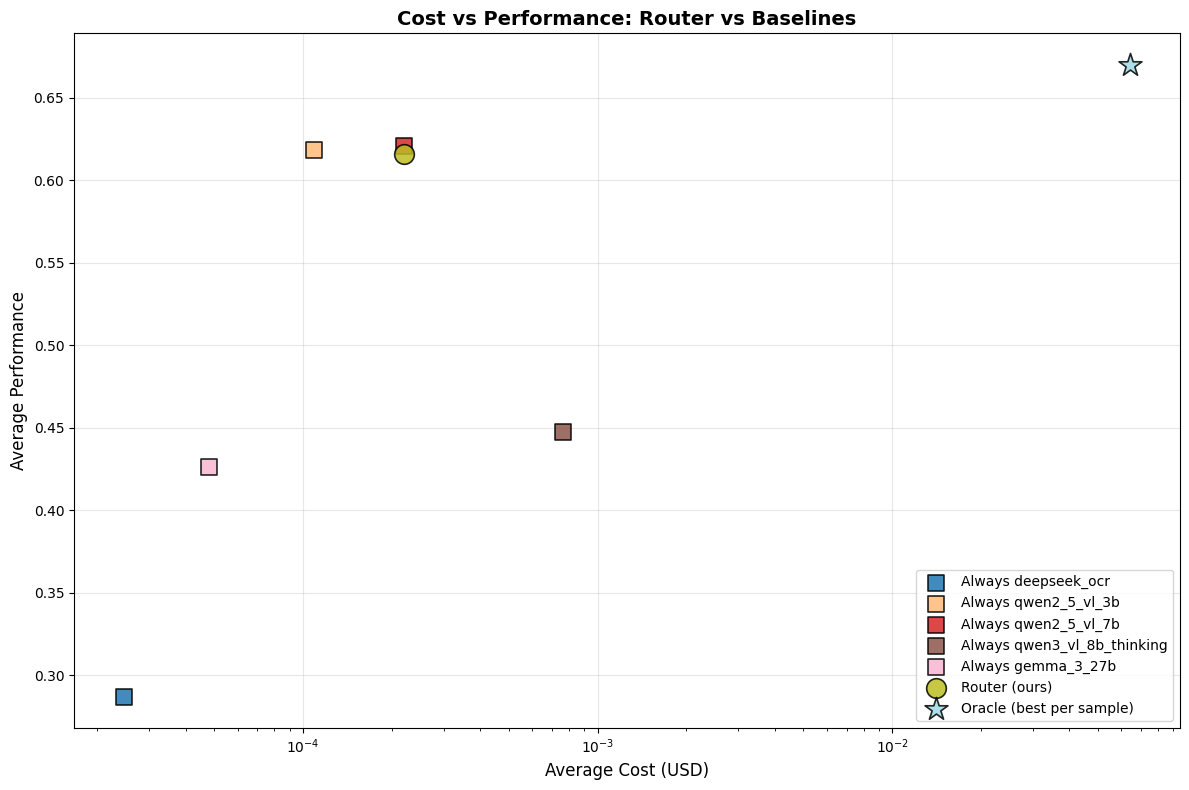

In [45]:
# === Pareto plot: Cost vs Performance (Router vs Baselines) ===

if "baseline_df" not in globals() or baseline_df.empty:
    print("No baseline data available for Pareto plot.")
else:
    fig, ax = plt.subplots(figsize=(12, 8))

    import matplotlib.cm as cm

    strategies = baseline_df["strategy"].unique()
    cmap = cm.get_cmap("tab20", len(strategies))
    strategy_to_color = {s: cmap(i) for i, s in enumerate(strategies)}

    for _, row in baseline_df.iterrows():
        strategy = row["strategy"]

        if "Router" in strategy:
            marker = "o"
            size = 200
            zorder = 10
        elif "Oracle" in strategy:
            marker = "*"
            size = 300
            zorder = 9
        else:
            marker = "s"
            size = 140
            zorder = 6

        color = strategy_to_color[strategy]

        ax.scatter(
            row["cost"],
            row["performance"],
            marker=marker,
            s=size,
            color=color,
            alpha=0.85,
            zorder=zorder,
            label=strategy,
            edgecolors="black",
            linewidths=1.2,
        )

    ax.set_xlabel("Average Cost (USD)", fontsize=12)
    ax.set_ylabel("Average Performance", fontsize=12)
    ax.set_title("Cost vs Performance: Router vs Baselines", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.set_xscale("log")

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), fontsize=10, loc="best")

    plt.tight_layout()

    if config.use_wandb and wandb is not None and wandb.run is not None:
        wandb.log({"test/cost_vs_performance": wandb.Image(fig)})

    plt.savefig(config.output_dir / "cost_vs_performance.png", dpi=150)
    plt.show()




=== Routing Patterns by Task ===


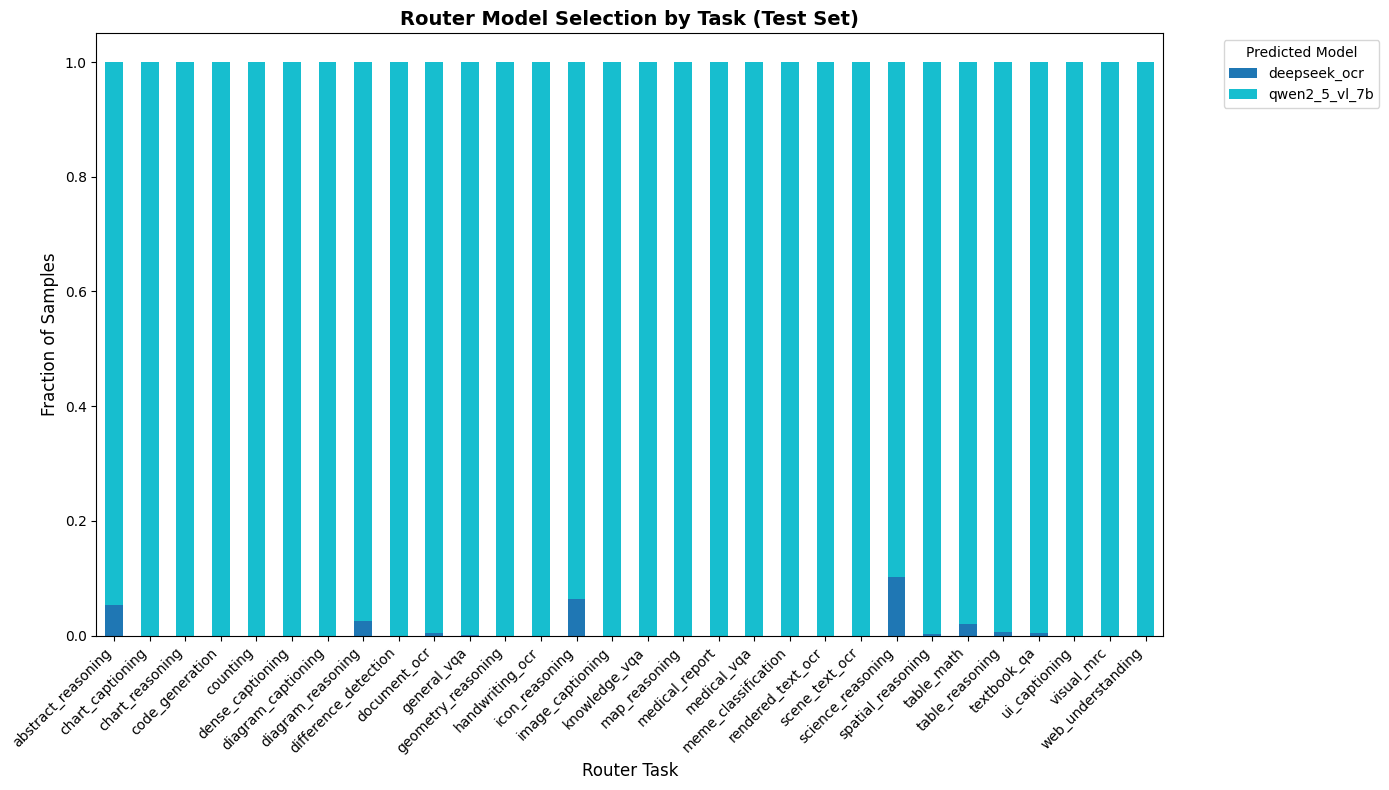

In [46]:
# === Routing Patterns by Task ===

if "router_task" not in test_df_eval.columns:
    print("router_task column not present; skipping routing pattern analysis.")
else:
    print("\n=== Routing Patterns by Task ===")

    task_routing = (
        test_df_eval
        .groupby("router_task")["router_predicted_model_name"]
        .value_counts(normalize=True)
        .rename("fraction")
        .reset_index()
    )

    task_routing_pivot = task_routing.pivot(
        index="router_task",
        columns="router_predicted_model_name",
        values="fraction",
    ).fillna(0)

    fig, ax = plt.subplots(figsize=(14, 8))
    task_routing_pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
    ax.set_xlabel("Router Task", fontsize=12)
    ax.set_ylabel("Fraction of Samples", fontsize=12)
    ax.set_title("Router Model Selection by Task (Test Set)", fontsize=14, fontweight="bold")
    ax.legend(title="Predicted Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if config.use_wandb and wandb is not None and wandb.run is not None:
        wandb.log({"test/routing_by_task": wandb.Image(fig)})

    plt.savefig(config.output_dir / "routing_by_task.png", dpi=150)
    plt.show()

    if config.use_wandb and wandb is not None and wandb.run is not None:
        wandb.log({"test/routing_by_task_table": wandb.Table(dataframe=task_routing)})



=== Overall Routing Distribution (Test Set) ===
router_predicted_model_name
qwen2_5_vl_7b    13603
deepseek_ocr       104
Name: count, dtype: int64

Fractions:
router_predicted_model_name
qwen2_5_vl_7b    0.992413
deepseek_ocr     0.007587
Name: count, dtype: float64


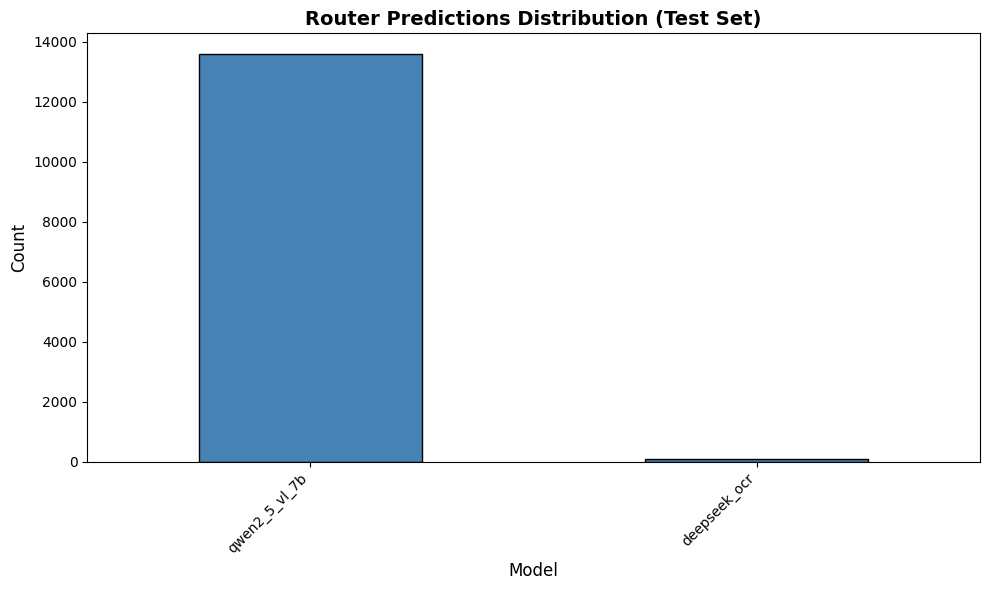

In [47]:
# === Overall Routing Distribution (Test Set) ===

routing_dist = test_df_eval["router_predicted_model_name"].value_counts()

print("\n=== Overall Routing Distribution (Test Set) ===")
print(routing_dist)
print("\nFractions:")
print(routing_dist / len(test_df_eval))

fig, ax = plt.subplots(figsize=(10, 6))
routing_dist.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Router Predictions Distribution (Test Set)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

if config.use_wandb and wandb is not None and wandb.run is not None:
    wandb.log({"test/routing_distribution": wandb.Image(fig)})

plt.savefig(config.output_dir / "routing_distribution.png", dpi=150)
plt.show()


In [48]:
# === Save test predictions to Parquet ===

cols_to_save = [
    "sample_id",
    "router_task",
    "source_dataset" if "source_dataset" in test_df_eval.columns else None,
    "router_best_model_name" if "router_best_model_name" in test_df_eval.columns else "router_best_model_id",
    "router_predicted_model_name",
    "router_chosen_perf" if "router_chosen_perf" in test_df_eval.columns else None,
    "router_actual_perf" if "router_actual_perf" in test_df_eval.columns else None,
    "router_chosen_cost" if "router_chosen_cost" in test_df_eval.columns else None,
    "router_actual_cost" if "router_actual_cost" in test_df_eval.columns else None,
]

cols_to_save = [c for c in cols_to_save if c is not None]

test_predictions_path = config.output_dir / "test_predictions.parquet"
test_df_eval[cols_to_save].to_parquet(test_predictions_path, index=False)

print(f"\nTest predictions saved to: {test_predictions_path}")

if config.use_wandb and wandb is not None and wandb.run is not None:
    artifact = wandb.Artifact(
        name=f"test-predictions-{wandb.run.id}",
        type="predictions",
        description="Test set predictions with performance and cost",
    )
    artifact.add_file(str(test_predictions_path))
    wandb.log_artifact(artifact)



Test predictions saved to: /storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_inference_outputs/test_predictions.parquet


In [49]:
# === Per-Class Metrics (Test Set) ===

precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, labels=range(num_models)
)

per_class_df = pd.DataFrame({
    "model": model_names,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support,
})

print("\n=== Per-Class Metrics (Test Set) ===")
print(per_class_df.to_string(index=False))

if config.use_wandb and wandb is not None and wandb.run is not None:
    wandb.log({"test/per_class_metrics": wandb.Table(dataframe=per_class_df)})



=== Per-Class Metrics (Test Set) ===
               model  precision   recall       f1  support
        deepseek_ocr   0.000000 0.000000 0.000000      396
       qwen2_5_vl_3b   0.000000 0.000000 0.000000     7352
       qwen2_5_vl_7b   0.278762 0.985959 0.434638     3846
qwen3_vl_8b_thinking   0.000000 0.000000 0.000000      147
         gemma_3_27b   0.000000 0.000000 0.000000     1966


/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [50]:
# === Per-class accuracy diagnostics (again, but aligned with test_* arrays) ===

per_class_acc = []
for cid in range(num_models):
    mask = (test_labels == cid)
    if mask.sum() == 0:
        per_class_acc.append(np.nan)
    else:
        per_class_acc.append((test_preds[mask] == test_labels[mask]).mean())

balanced_acc = np.nanmean(per_class_acc)
print(f"Overall acc   : {overall_accuracy:.4f}")
print(f"Balanced acc  : {balanced_acc:.4f}")

for cid, acc in enumerate(per_class_acc):
    print(f"  {model_names[cid]:<25}  acc_when_best = {acc:.3f}")

if config.use_wandb and wandb is not None and wandb.run is not None:
    wandb.log({
        "test/overall_acc_balanced": balanced_acc,
        **{f"test/class_acc/{model_names[i]}": float(per_class_acc[i])
           for i in range(num_models)},
    })


Overall acc   : 0.2766
Balanced acc  : 0.1972
  deepseek_ocr               acc_when_best = 0.000
  qwen2_5_vl_3b              acc_when_best = 0.000
  qwen2_5_vl_7b              acc_when_best = 0.986
  qwen3_vl_8b_thinking       acc_when_best = 0.000
  gemma_3_27b                acc_when_best = 0.000


In [51]:
model

'gemma_3_27b'

In [52]:
# ---- Collect router predictions on test set (sample-level) ----
@torch.no_grad()
def collect_test_predictions(model, loader, df_test, config):
    model.eval()
    all_preds = []
    all_labels = []
    all_sample_ids = []

    # We assume sequential sampler for DataLoader (default when shuffle=False)
    for batch_idx, batch in enumerate(loader):
        pixel_values = batch["pixel_values"].to(config.device)
        input_ids = batch["input_ids"].to(config.device)
        attention_mask = batch["attention_mask"].to(config.device)
        labels = batch["label"].to(config.device)

        logits = model(pixel_values, input_ids, attention_mask)
        preds = logits.argmax(dim=-1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        start_idx = batch_idx * config.eval_batch_size
        end_idx = start_idx + preds.size(0)
        batch_indices = list(range(start_idx, end_idx))
        sample_ids = df_test.iloc[batch_indices]["sample_id"].tolist()
        all_sample_ids.extend(sample_ids)

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    results = pd.DataFrame({
        "sample_id": all_sample_ids,
        "router_pred_model_id": all_preds,
        "router_label_id": all_labels,
    })

    # Attach human-readable model names if present
    if "router_best_model_name" in df_test.columns and "router_best_model_id" in df_test.columns:
        id_to_name = (
            df_test[["router_best_model_id", "router_best_model_name"]]
            .drop_duplicates()
            .set_index("router_best_model_id")["router_best_model_name"]
            .to_dict()
        )
        results["router_pred_model_name"] = results["router_pred_model_id"].map(id_to_name)

    return results


router_test_results = collect_test_predictions(model, test_loader, test_df, config)
print("Router test predictions preview:")
display(router_test_results.head())

# Also save for later analysis
# router_test_results_path = config.output_dir / "router_test_predictions.parquet"
# router_test_results.to_parquet(router_test_results_path, index=False)
# print("Saved router_test_results to:", router_test_results_path)


AttributeError: 'str' object has no attribute 'eval'

In [ ]:
# ---- Per-class accuracy diagnostics (test set) ----

# Build arrays from router_test_results
test_labels = router_test_results["router_label_id"].to_numpy()
test_preds  = router_test_results["router_pred_model_id"].to_numpy()

all_labels = test_labels
all_preds  = test_preds

per_class_acc = []
for cid in range(num_models):
    mask = (all_labels == cid)
    if mask.sum() == 0:
        per_class_acc.append(np.nan)
    else:
        per_class_acc.append((all_preds[mask] == all_labels[mask]).mean())

overall_acc = (all_labels == all_preds).mean()
balanced_acc = np.nanmean(per_class_acc)

print(f"Overall acc   : {overall_acc:.4f}")
print(f"Balanced acc  : {balanced_acc:.4f}")
print("\nPer-class accuracy (when that model is the true best):")
for cid, acc in enumerate(per_class_acc):
    print(f"  {model_names[cid]:<25}  acc_when_best = {acc:.3f}")

# Optional: bar plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(num_models)
ax.bar(x, per_class_acc)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha="right")
ax.set_ylabel("Accuracy when best")
ax.set_title("Per-class accuracy (conditioned on model being the true best)")
plt.tight_layout()
log_and_save_figure(fig, "per_class_accuracy_test")
plt.show()

# Log to W&B
if config.use_wandb and wandb is not None:
    wandb.log({
        "test/overall_acc": float(overall_acc),
        "test/balanced_acc": float(balanced_acc),
        **{f"test/class_acc/{model_names[i]}": float(per_class_acc[i])
           for i in range(num_models)},
    })


In [ ]:
# ---- Optional: finish W&B run when you're done ----
finish_wandb()